# Customer Churn Prediction

## 1. Business Problem
Customer churn is one of the biggest challenges faced by telecom companies. Because acquiring a new customer costs 5 to 7 times more than retaining an existing one, minimizing customer attrition is crucial for sustaining profitability and growth. 

## 2. Dataset
This project uses the **Telco Customer Churn dataset**, which contains information on 7,043 customers of a telecom company. It includes details such as:
- **Demographics:** Gender, senior citizen status, partner, and dependent status.
- **Services:** Phone service, multiple lines, internet service, online security, backup, device protection, tech support, and streaming TV/movies.
- **Account Information:** Tenure, contract type, paperless billing, payment method, monthly charges, and total charges.
- **Target Variable:** `Churn` (whether the customer left within the last month - Yes/No).

## 3. Objectives
- Perform exhaustive Exploratory Data Analysis (EDA) to understand the demographic and behavioral characteristics of churned vs. retained customers.
- Preprocess data and engineer domain-specific features to capture risk factors.
- Train, tune, and evaluate multiple machine learning classifiers to predict churn.
- Explain predictions using Explainable AI (SHAP) to drive proactive customer retention campaigns.

## 4. Success Metrics
- **Primary Metric:** **Recall / Sensitivity** (maximizing the identification of actual churners to prevent missed retention opportunities).
- **Secondary Metrics:** **ROC AUC** (overall ranking capability) and **F1-Score** (balance between Precision and Recall to optimize marketing budget).


In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import plotly.graph_objects as go
import warnings 
from pathlib import Path

# Configuring settings 
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Resolve dataset path dynamically based on project directory
data_path = Path("../../datasets/teleco/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Load dataset
df = pd.read_csv(data_path)

# Display shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display first 5 rows
df.head()


Dataset Shape: 7043 rows, 21 columns



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# structural information of the dataframe 
print("Dataset info")
print(df.info())
print("Summary Statistics")
print(df.describe(include='all'))

Dataset info
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str   

In [5]:
# dataset overview 
print(f"total customers: {df['customerID'].nunique()}")
print(f"total columns: {len(df.columns)}")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# customer_id is an identifier, removing from categorization list 
if 'customerID' in cat_cols:
    cat_cols.remove('customerID')
    
print(f"numerical columns({len(num_cols)}):{num_cols}")
print(f"Categorical Columns({len(cat_cols)}): {cat_cols}")

total customers: 7043
total columns: 21
numerical columns(3):['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical Columns(17): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [6]:
# missing values check and total charges conversion 
print("Initial nulls:\n", df.isnull().sum())

# check for blank space strings in TotolCharges 
blank_spaces = df[df['TotalCharges'].str.strip()==""]
print(f"\nNumber of rows with blank space in 'TotalCharges:{len(blank_spaces)}")

# convert empty strings to NaN and parse to float 
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = df['TotalCharges'].astype(float) 

# show that conversion was successful 
print("\nAfter Conversion Info:")
print(df[['tenure','MonthlyCharges', 'TotalCharges']].isnull().sum())

Initial nulls:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Number of rows with blank space in 'TotalCharges:11

After Conversion Info:
tenure             0
MonthlyCharges     0
TotalCharges      11
dtype: int64


In [7]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows in dataset: {duplicates}")
for col in cat_cols:
    print(f"{col}:{df[col].unique()}")

Number of duplicate rows in dataset: 0
gender:<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner:<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents:<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService:<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines:<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService:<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity:<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup:<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection:<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport:<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV:<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies:<ArrowStringArray>
['No', 'Yes', 'No internet s

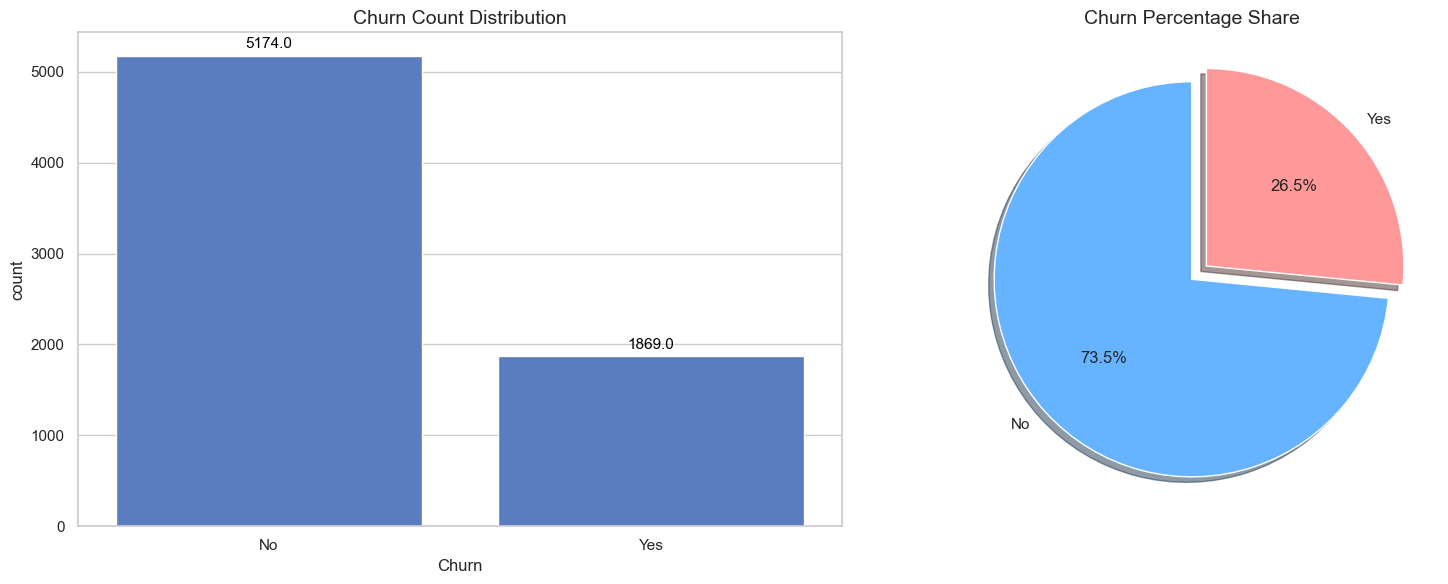

Observation:
- Retained Customers (No): 5174 (73.46%)
- Churned Customers (Yes): 1869 (26.54%)
- The dataset is moderately imbalanced (approx. 26.5% churn). This must be handled during modeling.


In [8]:
# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Countplot
sns.countplot(x='Churn', data=df, ax=axes[0], order=['No', 'Yes'])
axes[0].set_title('Churn Count Distribution', fontsize=14)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height() + 50),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff','#ff9999'], explode=(0, 0.1), shadow=True)
axes[1].set_title('Churn Percentage Share', fontsize=14)

plt.tight_layout()
plt.show()

# Print text observation
print(f"Observation:\n- Retained Customers (No): {churn_counts['No']} ({churn_counts['No']/len(df)*100:.2f}%)")
print(f"- Churned Customers (Yes): {churn_counts['Yes']} ({churn_counts['Yes']/len(df)*100:.2f}%)")
print("- The dataset is moderately imbalanced (approx. 26.5% churn). This must be handled during modeling.")


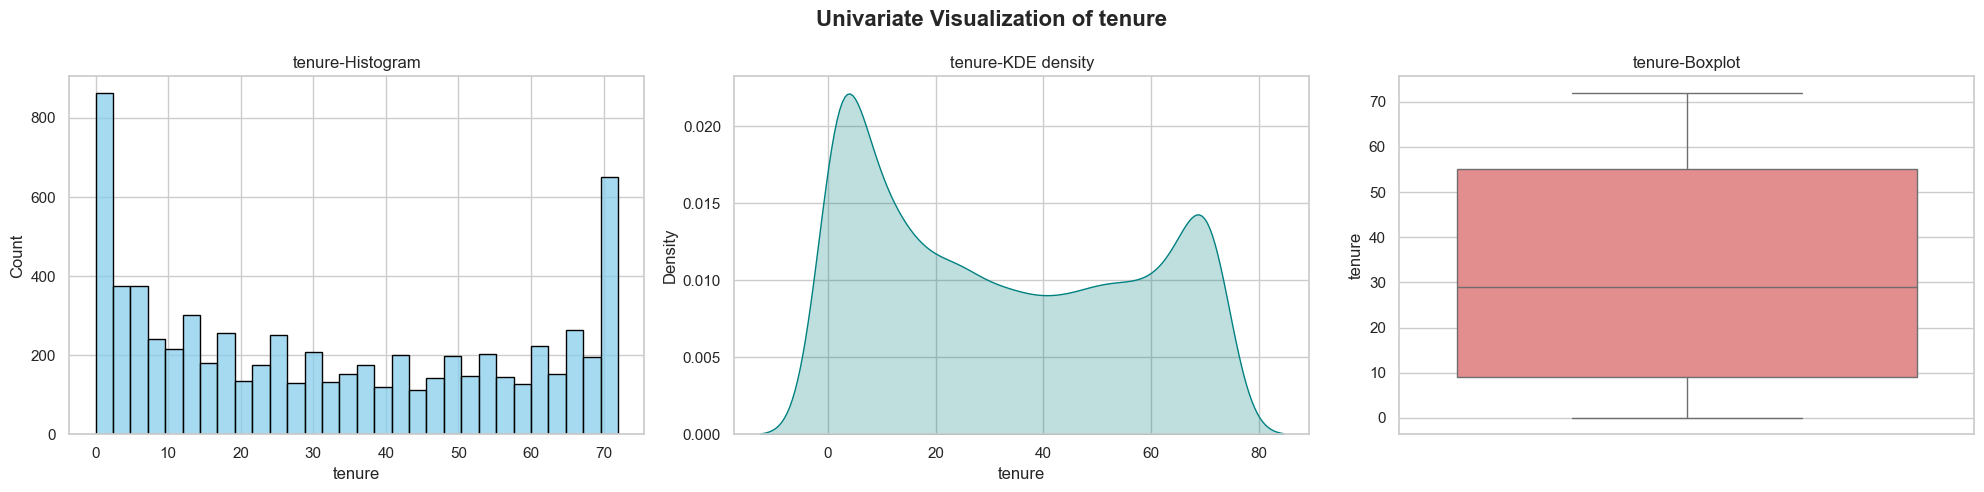

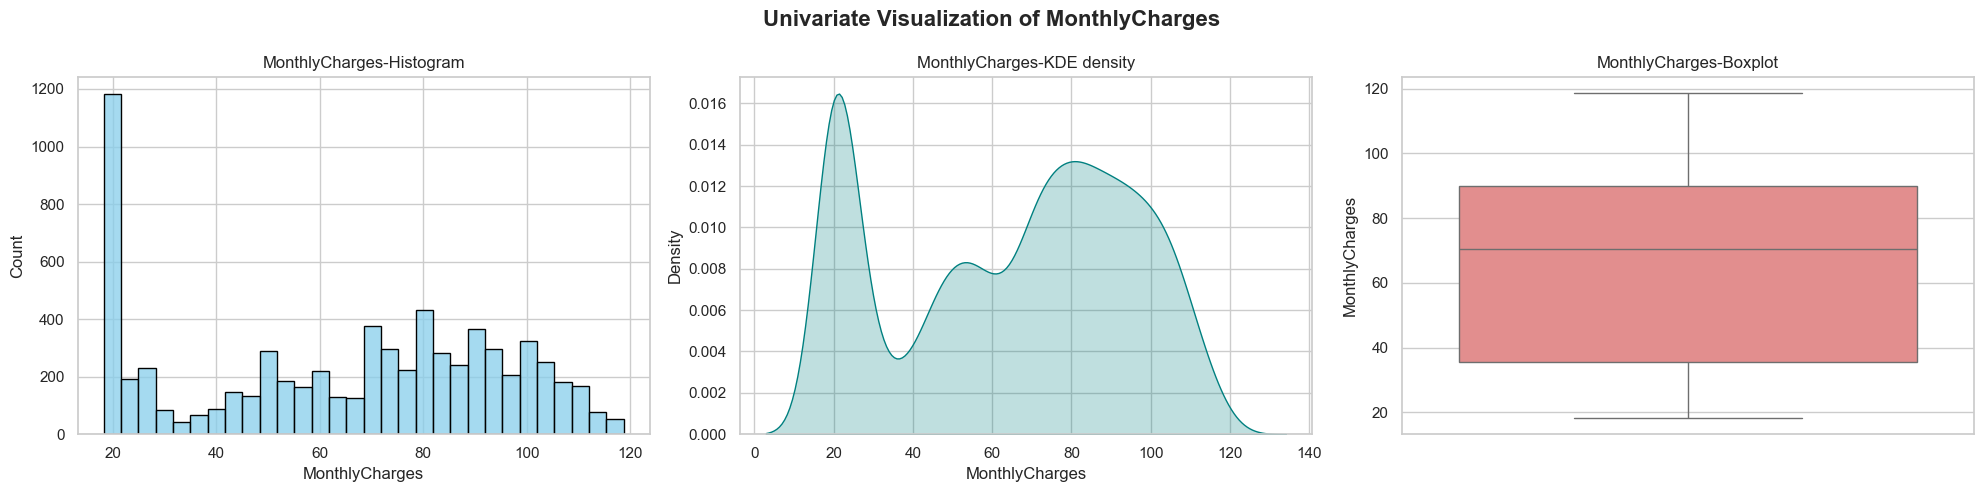

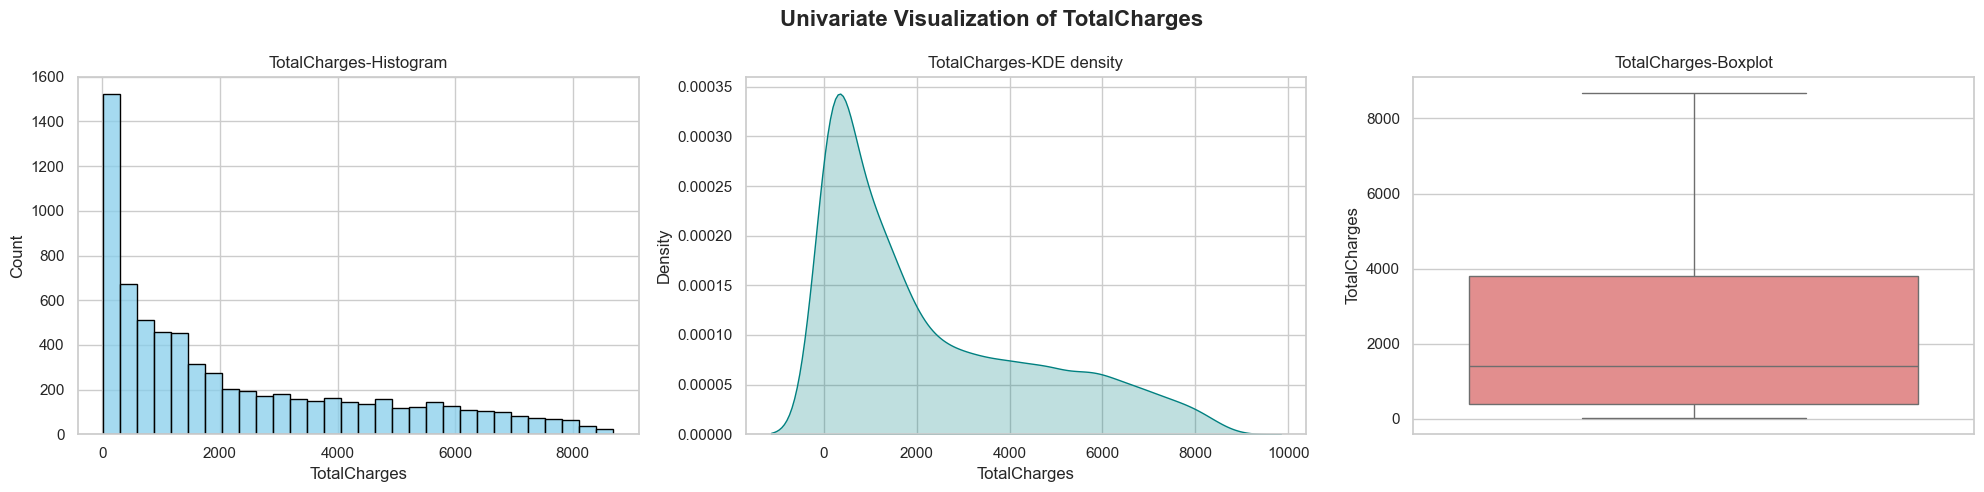

In [9]:
# univariate analysis and numerical column 
num_features = ['tenure', 'MonthlyCharges','TotalCharges']

for feat in num_features:
    fig, axes = plt.subplots(1,3,figsize=(20,5))
    sns.histplot(df[feat], bins=30, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f'{feat}-Histogram')

    # KDE plot
    sns.kdeplot(df[feat], ax=axes[1], color='teal', fill=True)
    axes[1].set_title(f'{feat}-KDE density')

    # boxplot
    sns.boxplot(y=df[feat], ax=axes[2], color='lightcoral')
    axes[2].set_title(f'{feat}-Boxplot')

    plt.suptitle(f'Univariate Visualization of {feat}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

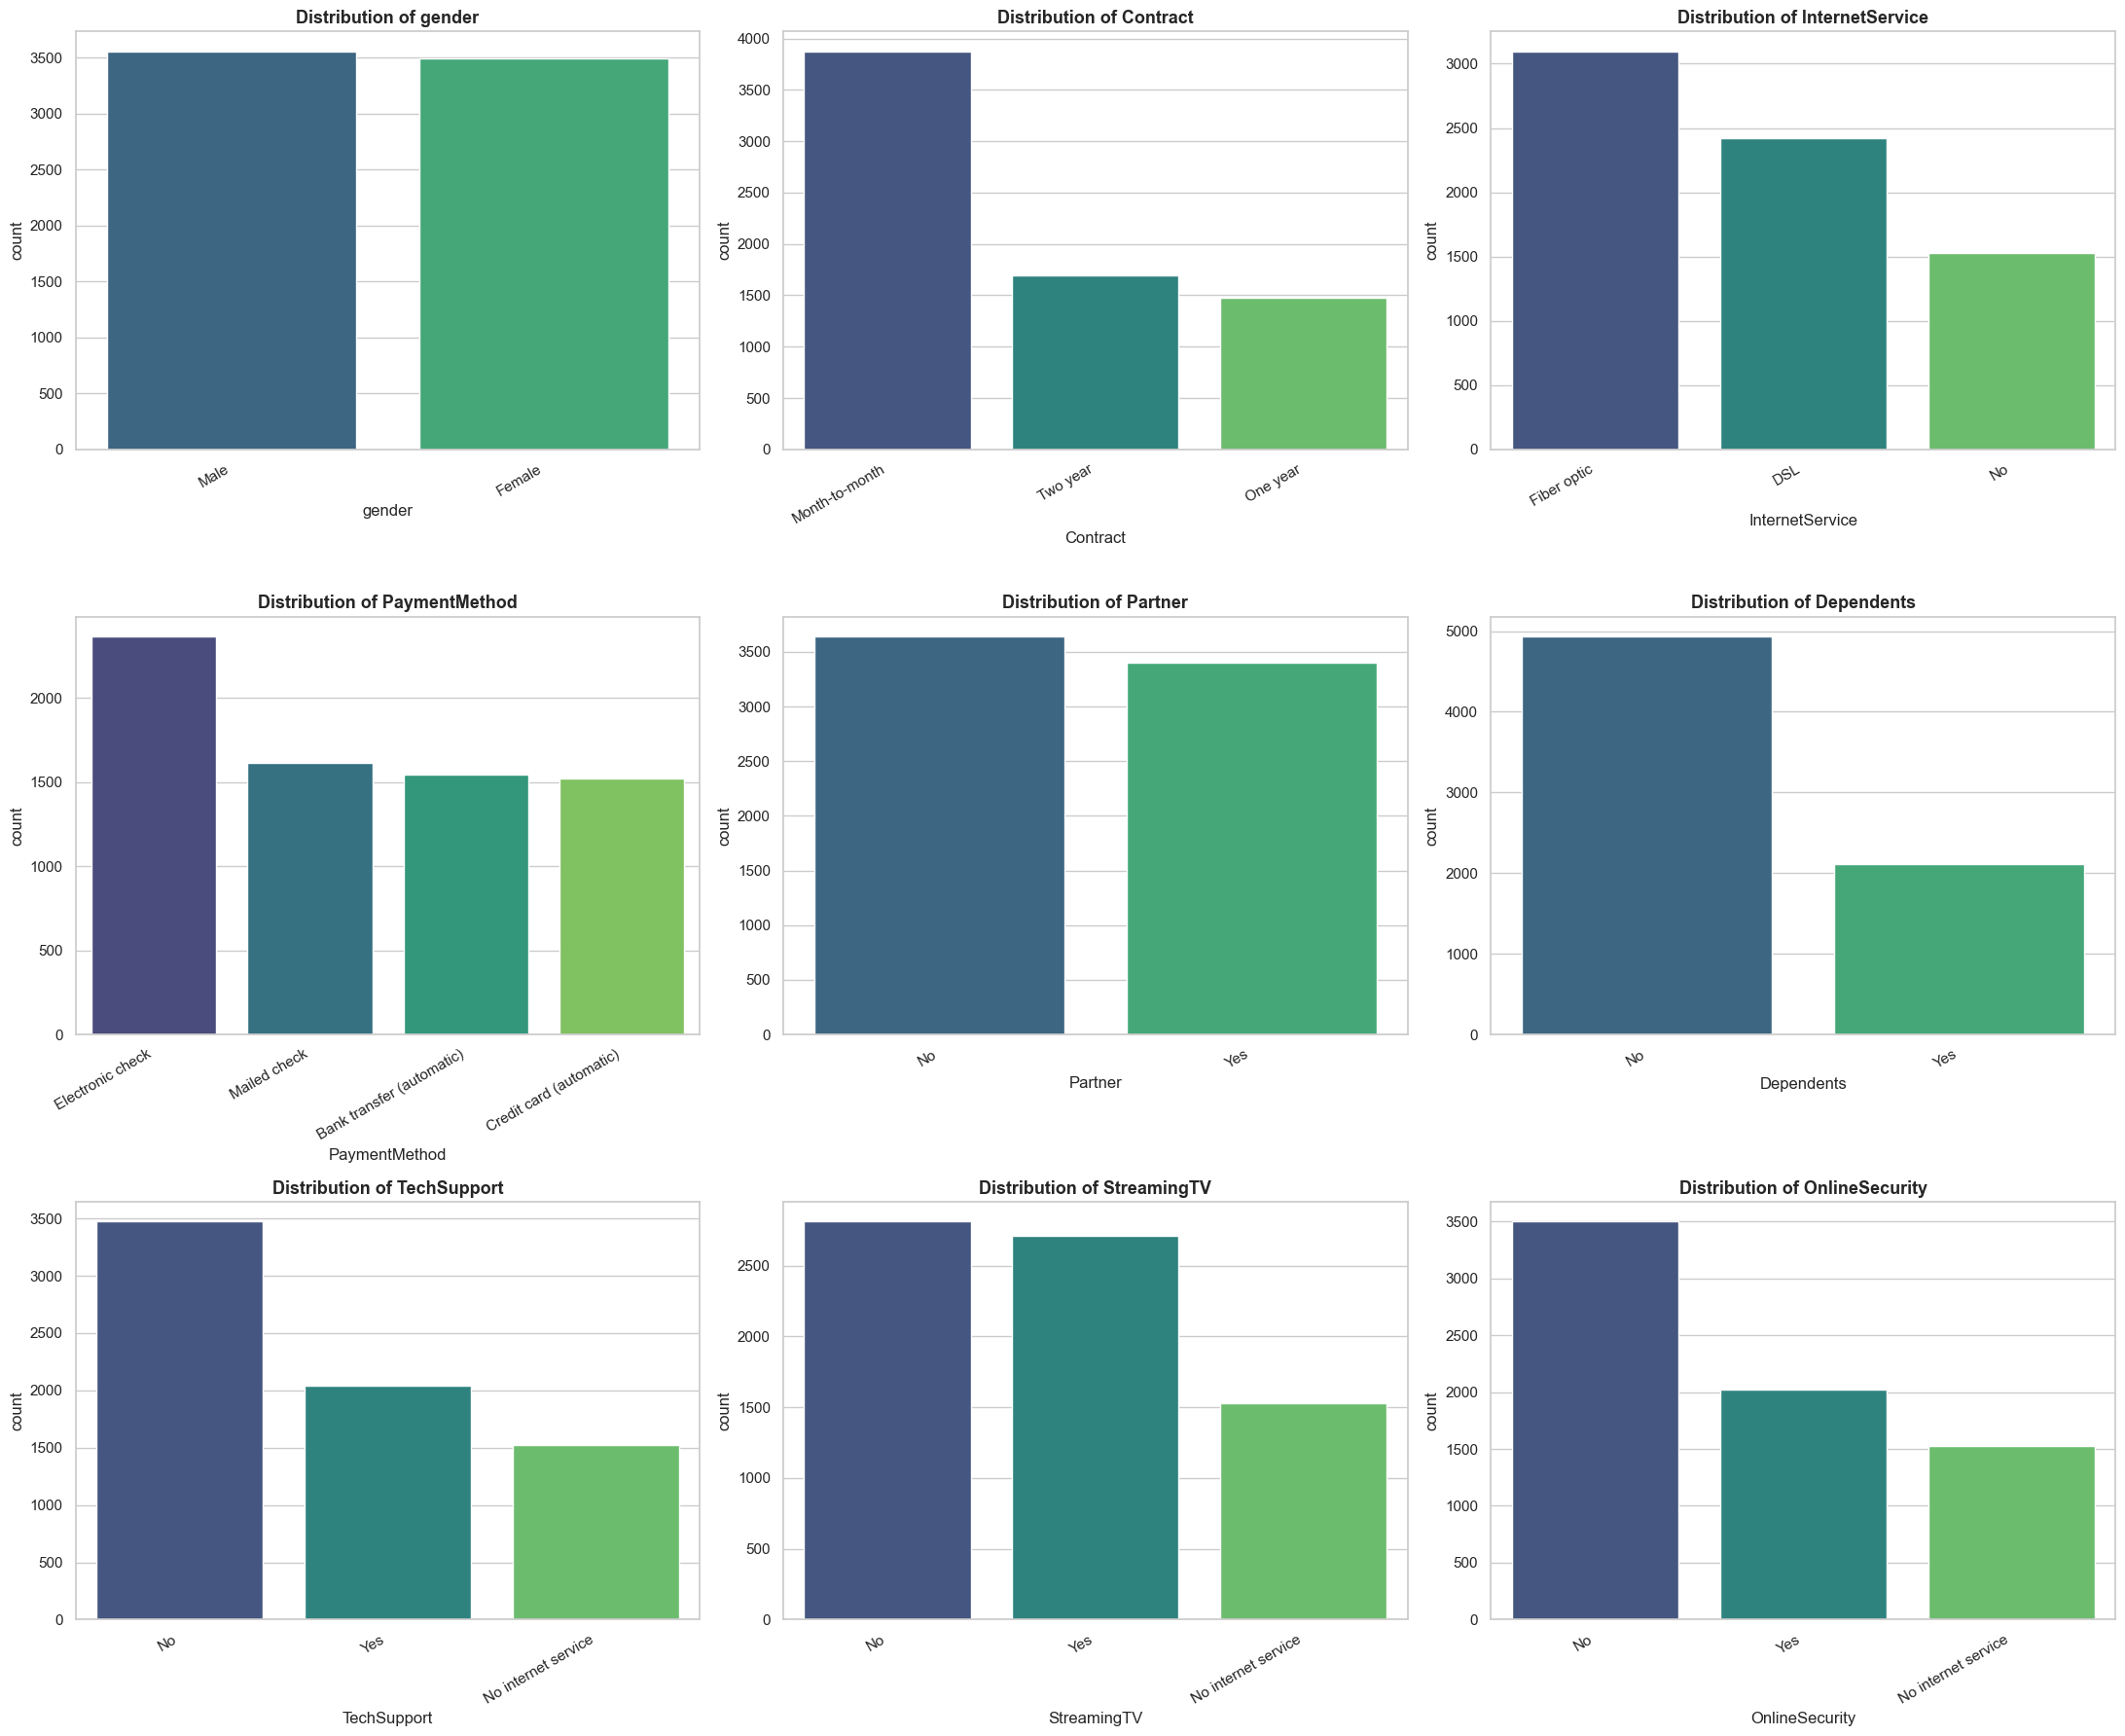

In [10]:
cat_features_to_plot = ['gender', 'Contract', 'InternetService', 'PaymentMethod', 
                         'Partner', 'Dependents', 'TechSupport', 'StreamingTV', 'OnlineSecurity']

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
axes = axes.flatten()

for idx, col in enumerate(cat_features_to_plot):
    sns.countplot(x=col, data=df, ax=axes[idx], palette='viridis', order=df[col].value_counts().index)
    axes[idx].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=30, ha='right')
    
plt.tight_layout()
plt.show()



 Churn rate by Contract(%)
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


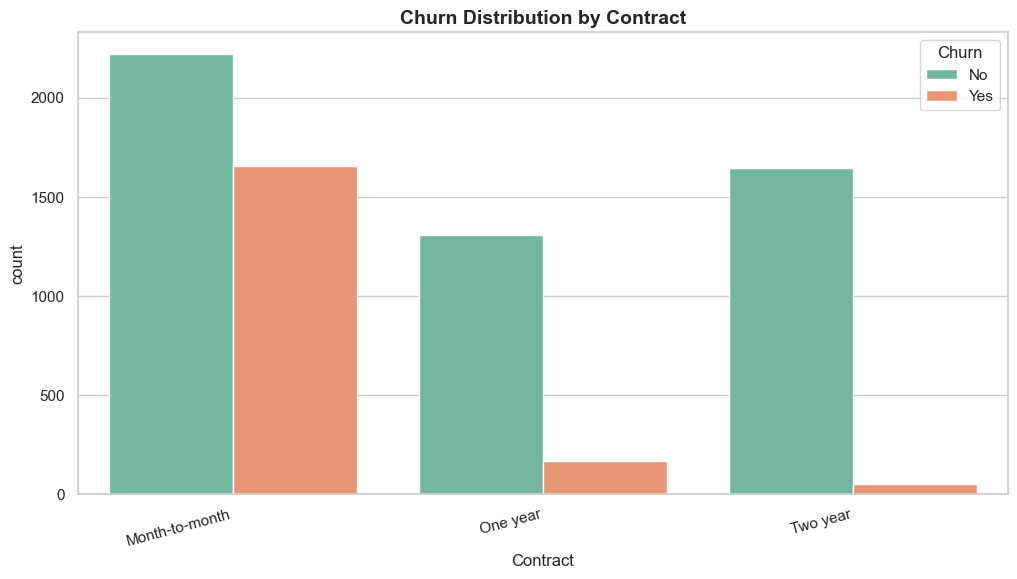


 Churn rate by PaymentMethod(%)
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


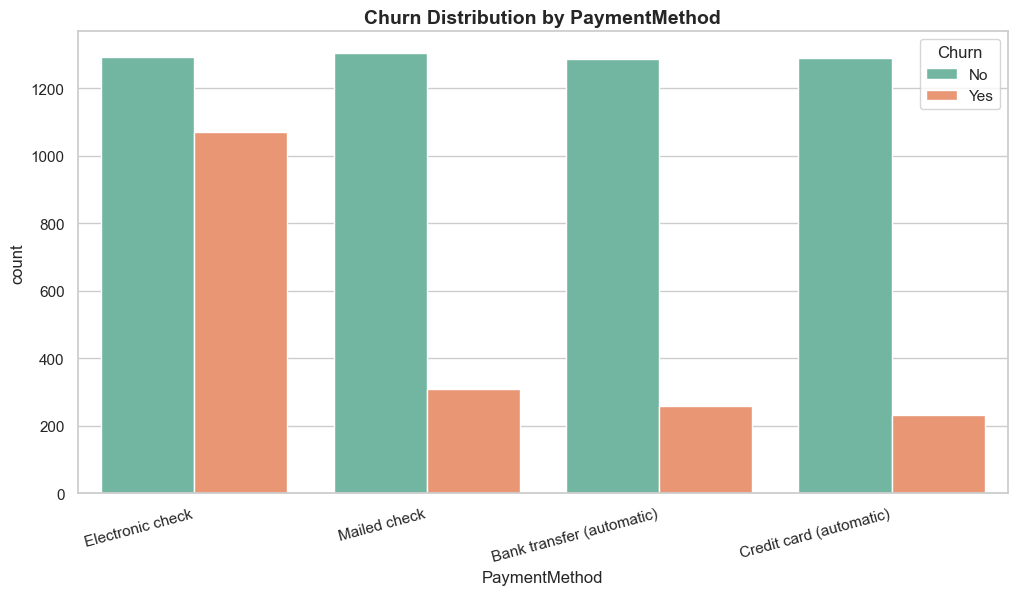


 Churn rate by InternetService(%)
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


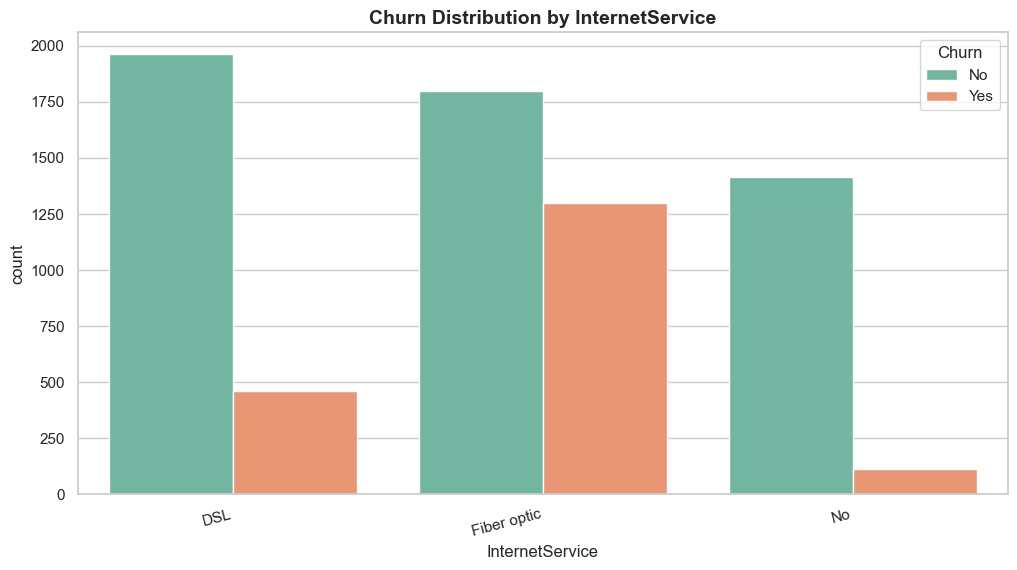

In [12]:
# bivariate analysis 
biv_cols = ['Contract', 'PaymentMethod', 'InternetService']
for col in biv_cols:
    plt.figure(figsize=(12,6))
    sns.countplot(x=col, hue='Churn', data=df, palette='Set2')
    plt.title(f'Churn Distribution by {col}',fontsize=14, fontweight='bold')
    plt.xticks(rotation=15, ha='right')
    plt.legend(title='Churn', loc='upper right')

    # calculate churn rates for analysis
    rates = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()*100
    print(f"\n Churn rate by {col}(%)")
    print(rates.round(2))
    plt.show()

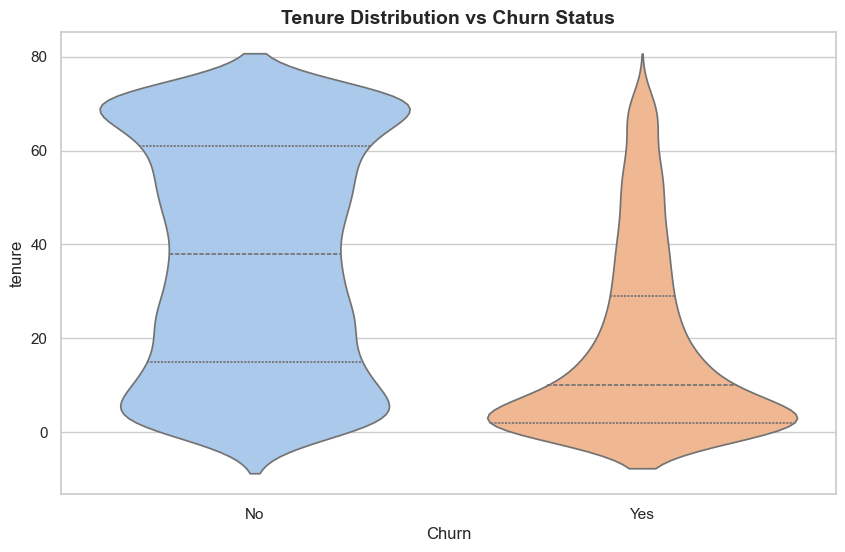

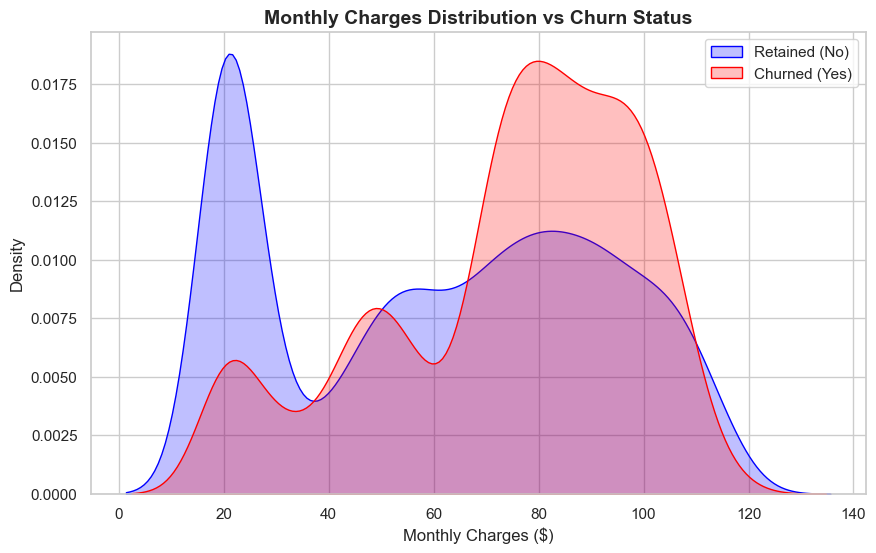

In [13]:
# bivariate analysis, tenure violin and monthly charges 
# Tenure Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Churn', y='tenure', data=df, palette='pastel', inner='quartile')
plt.title('Tenure Distribution vs Churn Status', fontsize=14, fontweight='bold')
plt.show()

# Monthly Charges KDE Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], fill=True, color='blue', label='Retained (No)')
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], fill=True, color='red', label='Churned (Yes)')
plt.title('Monthly Charges Distribution vs Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.legend()
plt.show()


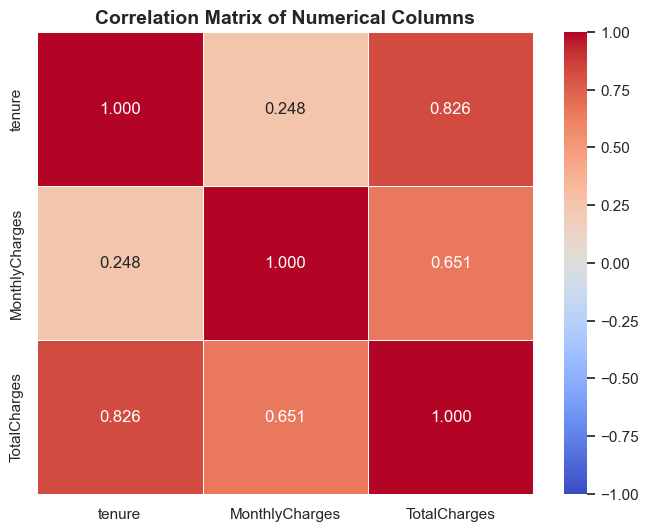

In [14]:
# correlation on numerical field 
plt.figure(figsize=(8,6))
corr_matrix = df[['tenure','MonthlyCharges','TotalCharges']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt=".3f",linewidths=0.5,vmin=-1,vmax=1)
plt.title('Correlation Matrix of Numerical Columns', fontsize=14, fontweight='bold')
plt.show()

## Key Insights from Exploratory Data Analysis (EDA)

1. **High Churn Rate in Month-to-Month Contracts:** Customers with month-to-month agreements churn at a significantly higher rate (~42.7%) compared to one-year (~11.3%) and two-year contract holders (~2.8%).
2. **Electronic Check Risk Factor:** Customers utilizing 'Electronic Check' as their payment method display a churn rate of ~45.3%, which is much higher than any other payment method (which hover around 15-20%).
3. **Fiber Optic Attrition:** Fiber optic internet service subscribers exhibit high churn rates (~41.9%) compared to DSL users (~19.0%), suggesting potential issues with connection stability, customer expectations, or pricing.
4. **Early-Life Churn Peak:** The tenure violin plot shows that churned customers are heavily clustered around low tenure (0-6 months), pointing to onboarding difficulties or unfulfilled expectations.
5. **High Monthly Charges Drive Churn:** Churned customers have a density peak around monthly costs of $70–$100, indicating cost-sensitivity among subscribers.
6. **Support Features Retain Customers:** Features like `OnlineSecurity`, `OnlineBackup`, and `TechSupport` show noticeably lower churn rates when activated ("Yes") compared to when deactivated ("No").
7. **No Phone Service Churns Less:** Customers without phone service (only utilizing internet) churn at a lower rate (~24.9%) than those with multiple lines (~28.6%).
8. **Imbalanced Target:** Only 26.5% of the entries are churn cases. We must apply techniques like SMOTE during modeling to avoid biased models.
9. **TotalCharges Correlation:** `TotalCharges` is heavily collinear with `tenure` (0.82) and `MonthlyCharges` (0.65). Multicollinearity must be monitored during feature preprocessing.
